Spacing metrics:
- Convex hull: offensive defensive convex hull to see which offenses strech out more the defense and which defenses are more compact.
- Average distance to a defender: 
- Gravity: for each offensive player calculate the distance to the nearest defender
- Voronoi diagram including player velocities and accelerations
-Radius of gyration?

Another way to measure a player’s impact beyond traditional scoring is by analyzing how they influence defensive spacing. For instance, LeBron James is known for his versatility: he can attack the basket, shoot from the perimeter, or create opportunities for teammates, forcing defenders to cover more of the floor and constantly adjust. In contrast, a player like Joel Embiid, who dominates near the rim, naturally pulls defenders inward, compressing the defense. Using an adjusted plus/minus framework, analysts can quantify this effect by using defensive spread — i.e., the average distance defenders are forced to cover — as the dependent variable instead of point differential. This method allows for measuring how different players, such as LeBron versus Embiid, stretch or compress defenses, providing a more nuanced understanding of a player’s impact beyond traditional box score statistics.

 #EVENTMSGTYPE
 - #1 - Make 
 - #2 - Miss 
 - #3 - Free Throw 
-  #4 - Rebound 
 - #5 - out of bounds / Turnover / Steal 
-  #6 - Personal Foul 
 - #7 - Violation 
 - #8 - Substitution 
 - #9 - Timeout 
 - #10 - Jumpball 
 - #12 - Start Q1? 
 - #13 - Start Q2?


In [1]:
from game import Game

game = Game('12.11.2015', 'BOS', 'GSW')

Download complete. Extracting...
Extraction complete.
Play-by-play download complete.
All data is loaded


In [2]:
import pandas as pd

# change this path if you want a different file
path = "../data/shot_features_full.csv"

df = pd.read_csv(path, usecols=["player_name", "team_id", "game_id"])

summary = (
    df.groupby("team_id")
      .agg(
          distinct_shooters=("player_name", "nunique"),
          total_shots=("player_name", "size"),
          distinct_games=("game_id", "nunique"),
      )
      .sort_values("total_shots", ascending=False)
      .reset_index()
)

print(summary)

       team_id  distinct_shooters  total_shots  distinct_games
0   1610612757                 15         3519              44
1   1610612766                 14         3401              42
2   1610612743                 16         3370              43
3   1610612738                 15         3343              40
4   1610612752                 14         3340              43
5   1610612760                 14         3318              42
6   1610612744                 14         3305              41
7   1610612754                 14         3302              41
8   1610612737                 15         3291              43
9   1610612765                 15         3287              41
10  1610612747                 15         3285              42
11  1610612742                 15         3275              42
12  1610612753                 15         3230              41
13  1610612756                 16         3206              41
14  1610612758                 14         3202         

In [4]:
import pandas as pd

path = "../data/shot_features_full.csv"
df = pd.read_csv(path, usecols=["description"])

desc = df["description"].fillna("").astype(str)

is_3pt = desc.str.contains(r"\b3pt\b", case=False, regex=True)
is_miss = desc.str.contains(r"\bmiss\b", case=False, regex=True)
is_make = ~is_miss

total_shots = len(df)
three_pt_shots = is_3pt.sum()
three_pt_makes = (is_3pt & is_make).sum()

print(f"total shots: {total_shots}")
print(f"3PT shots: {three_pt_shots}")
print(f"3PT make rate: {three_pt_makes / three_pt_shots:.3%}" if three_pt_shots else "3PT make rate: N/A")
print(f"overall make rate: {is_make.sum() / total_shots:.3%}")

total shots: 95219
3PT shots: 27543
3PT make rate: 35.334%
overall make rate: 44.861%


In [22]:
import pandas as pd


df = pd.read_csv("../data/shot_features_full.csv", usecols=["description", "time_to_contest", "made_shot"])
desc = df["description"].fillna("").astype(str)

if "is_3_pointer" in df.columns:
    df = df[df["is_3_pointer"] == 1].copy()
else:
    desc = df["description"].fillna("").astype(str)
    df = df[desc.str.contains(r"\b3pt\b", case=False, regex=True)].copy()

print(f"Kept {len(df)} / {len(df)} rows as 3-pointers")


with_ttc = df[df['time_to_contest'].notna()]
no_ttc = df[df['time_to_contest'].isna()]

under = with_ttc[with_ttc['time_to_contest'] <= 0.5]  # <=0.4s => "under"
over  = with_ttc[with_ttc['time_to_contest'] >  0.5]

def stats(sub):
    n = len(sub)
    makes = int(sub['made_shot'].sum())
    return n, makes, (makes / n) if n > 0 else float('nan')

n_u, m_u, r_u = stats(under)
n_o, m_o, r_o = stats(over)
n_all, m_all, r_all = stats(df)

print(f"time_to_contest <= 0.4s: n={n_u}, makes={m_u}, make_rate={r_u:.4%}")
print(f"time_to_contest >  0.4s: n={n_o}, makes={m_o}, make_rate={r_o:.4%}")
print(f"ALL (made_shot present): n={n_all}, makes={m_all}, make_rate={r_all:.4%}")



Kept 27543 / 27543 rows as 3-pointers
time_to_contest <= 0.4s: n=10230, makes=3548, make_rate=34.6823%
time_to_contest >  0.4s: n=17297, makes=6179, make_rate=35.7230%
ALL (made_shot present): n=27543, makes=9732, make_rate=35.3338%


In [2]:
%matplotlib inline

In [13]:
from visualization import plot_frame

from game import Game

game = Game('12.11.2015', 'BOS', 'GSW')

frame=game.get_frame(2538.1)
plot_frame(game,frame)

Download complete. Extracting...
Extraction complete.
Play-by-play download complete.
All data is loaded


Saving video to c:\Users\juanm\Documents\KUL_MAI\TFM\TFM-KUL-Juan\src\temp\2538.mp4...


KeyError: 10

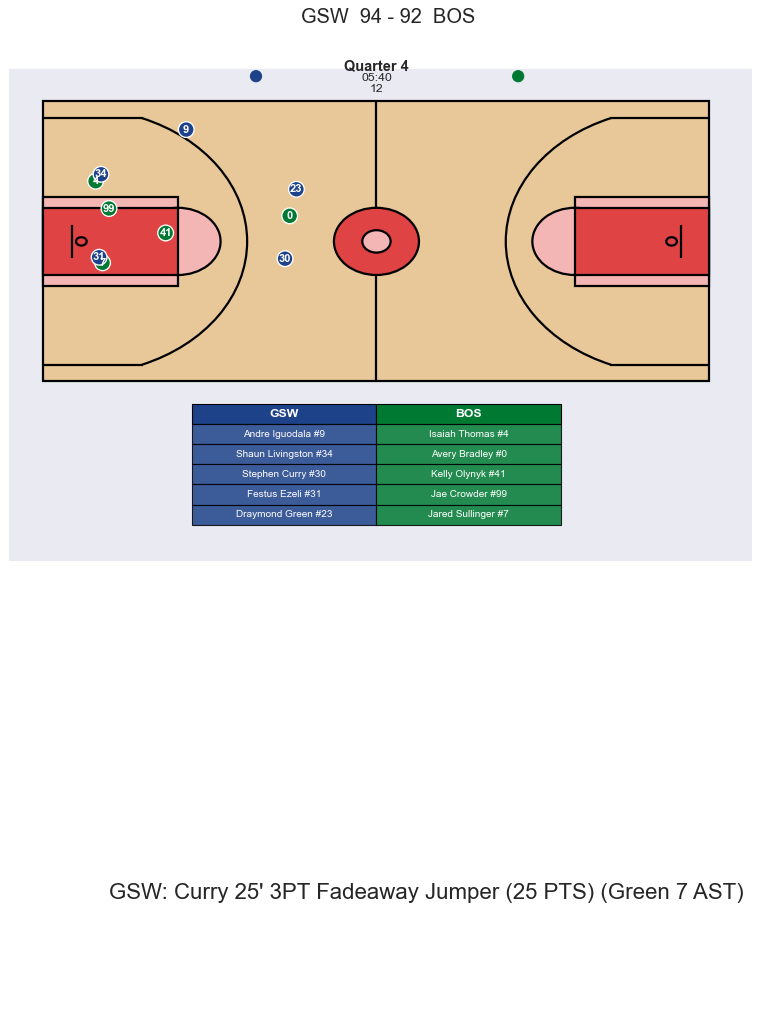

In [27]:
from visualization import plot_frame,animate_play
frame=game.get_frame(2538.1)
plot_frame(game,frame,show_velocity=True,show_control=True,use_time_control=True)
animate_play(game, 2538, 10, 
              show_velocity=True, show_control=True, use_time_control=False)

In [12]:
import pandas as pd
df = pd.read_csv('../data\shot_features_full.csv', low_memory=False)
# Curry shots in GSW@CLE 0021500622, Q3
curry = df[(df['game_id'].isin([21500622, '0021500622'])) &
           (df['player_name'] == 'Stephen Curry') &
           (df['quarter'] == 3)]
curry.head(1)

,player_name,game_time,quarter,score_margin,team_id,game_id,description,closest_def_name,made_shot,dist,...,Prob_Cluster_1,Prob_Cluster_2,Prob_Cluster_3,Prob_Cluster_4,Prob_Cluster_5,Def_Prob_Cluster_1,Def_Prob_Cluster_2,Def_Prob_Cluster_3,Def_Prob_Cluster_4,Def_Prob_Cluster_5
14191,Stephen Curry,1527,3,32,1610612744,21500622,Curry 24 3PT Jump Shot (24 PTS) (Green 7 AST),Kyrie Irving,1,24.865592,...,0.959123,0.000073,1.714692e-08,2.348268e-25,0.040803,0.000001,0.009948,0.930668,8.274156e-07,0.059383


In [8]:
frame=game.get_frame(2538.1)
plot_frame(game,frame)

In [3]:
from PIL import Image

img1 = Image.open("../thesis_drafts/figures/release_frame_recovery.png")
img2 = Image.open("../klay_release_v2.png")

merged = Image.new(
    "RGBA",
    (img1.width + img2.width, max(img1.height, img2.height)),
    (255, 255, 255, 0),
)

merged.paste(img1, (0, 0), img1)
merged.paste(img2, (img1.width, 0), img2)

merged.save("merged.png")
merged.save("merged.png")

In [2]:
# src/build_shots_with_lineup.py
import os, time, requests
import pandas as pd
from pbpstats.client import Client
from nba_api.stats.endpoints import LeagueGameFinder

SEASON      = '2015-16'
SEASON_TYPE = 'Regular Season'
OUT         = 'data/shots_with_lineup.csv'

# ---- 1. Pull the season's game IDs via nba_api (not pbpstats) ------------
# Has a 30 s default timeout and is the single most reliable NBA Stats call.
games_df = LeagueGameFinder(
    season_nullable=SEASON,
    season_type_nullable=SEASON_TYPE,
    league_id_nullable='00',
    timeout=60,
).get_data_frames()[0]

# Each game appears twice (once per team) - dedupe
game_ids = sorted(games_df['GAME_ID'].unique().tolist())
print(f'Season {SEASON} has {len(game_ids)} games')

# ---- 2. Use pbpstats only for per-game lineup/possession data -----------
client = Client({
    'Games':       {'source': 'web', 'data_provider': 'stats_nba'},
    'Possessions': {'source': 'web', 'data_provider': 'stats_nba'},
})

# Resume support
already = set()
if os.path.exists(OUT):
    already = set(pd.read_csv(OUT, usecols=['game_id'], dtype=str)['game_id'])
    print(f'Resuming: {len(already)} games already processed')

games_left = [g for g in game_ids if g not in already]
print(f'Games to process: {len(games_left)}')

def fetch_game(gid, retries=5, base_wait=4.0):
    for k in range(retries):
        try:
            return client.Game(gid)
        except Exception as e:
            wait = base_wait * (2 ** k)
            print(f'    retry {k+1}/{retries} after {wait:.0f}s '
                  f'({type(e).__name__})')
            time.sleep(wait)
    return None

BUFFER, FLUSH_EVERY = [], 25
header_written = os.path.exists(OUT)

for i, game_id in enumerate(games_left, 1):
    g = fetch_game(game_id)
    if g is None:
        print(f'  [{i}/{len(games_left)}] PERMANENT FAIL {game_id}')
        continue

    for poss in g.possessions.items:
        lineups = poss.players
        for ev in poss.events:
            if ev.__class__.__name__ != 'FieldGoal':
                continue
            off_tid = ev.team_id
            def_tid = next(t for t in lineups if t != off_tid)
            BUFFER.append({
                'game_id'        : str(game_id),
                'period'         : ev.period,
                'pc_time'        : str(ev.clock),
                'shooter_id'     : ev.player1_id,
                'made_shot'      : int(ev.is_made),
                'shot_value'     : ev.shot_value,
                'shot_distance'  : getattr(ev, 'distance', None),
                'off_team_id'    : off_tid,
                'def_team_id'    : def_tid,
                'off_lineup_ids' : '|'.join(str(p) for p in sorted(lineups[off_tid])),
                'def_lineup_ids' : '|'.join(str(p) for p in sorted(lineups[def_tid])),
            })

    if i % FLUSH_EVERY == 0 and BUFFER:
        pd.DataFrame(BUFFER).to_csv(OUT, mode='a', index=False,
                                    header=not header_written)
        header_written = True
        BUFFER.clear()
        print(f'  [{i}/{len(games_left)}] flushed - last game {game_id}')
    time.sleep(1.0)   # polite delay between games

if BUFFER:
    pd.DataFrame(BUFFER).to_csv(OUT, mode='a', index=False,
                                header=not header_written)
print('finished')

Season 2015-16 has 1230 games
Games to process: 1230
    retry 1/5 after 4s (KeyError)
    retry 2/5 after 8s (KeyError)
    retry 3/5 after 16s (KeyError)
    retry 4/5 after 32s (KeyError)
    retry 5/5 after 64s (KeyError)
  [1/1230] PERMANENT FAIL 0021500001
    retry 1/5 after 4s (KeyError)
    retry 2/5 after 8s (KeyError)
    retry 3/5 after 16s (KeyError)
    retry 4/5 after 32s (KeyError)


KeyboardInterrupt: 

In [3]:
# src/build_shots_with_lineup.py
import os, time
import pandas as pd

# ---- 0. Monkey-Patch Requests to Bypass NBA API Bot Blocks ----------------
# pbpstats uses python's requests library. We intercept the Session request 
# to force-inject headers so stats.nba.com behaves like a regular browser.
import requests
original_request = requests.Session.request

def patched_request(self, method, url, *args, **kwargs):
    if 'stats.nba.com' in url:
        if 'headers' not in kwargs or kwargs['headers'] is None:
            kwargs['headers'] = {}
        kwargs['headers'].update({
            'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/122.0.0.0 Safari/537.36',
            'Referer': 'https://www.nba.com/',
            'Origin': 'https://www.nba.com',
            'Accept': 'application/json, text/plain, */*',
            'Accept-Language': 'en-US,en;q=0.9',
        })
    return original_request(self, method, url, *args, **kwargs)

requests.Session.request = patched_request
# ---------------------------------------------------------------------------

from pbpstats.client import Client
from nba_api.stats.endpoints import LeagueGameFinder

SEASON      = '2015-16'
SEASON_TYPE = 'Regular Season'
OUT         = 'data/shots_with_lineup.csv'

# ---- 1. Pull the season's game IDs via nba_api (not pbpstats) ------------
games_df = LeagueGameFinder(
    season_nullable=SEASON,
    season_type_nullable=SEASON_TYPE,
    league_id_nullable='00',
    timeout=60,
).get_data_frames()[0]

game_ids = sorted(games_df['GAME_ID'].unique().tolist())
print(f'Season {SEASON} has {len(game_ids)} games')

# ---- 2. Use pbpstats only for per-game lineup/possession data -----------
client = Client({
    'Games':       {'source': 'web', 'data_provider': 'stats_nba'},
    'Possessions': {'source': 'web', 'data_provider': 'stats_nba'},
})

# Resume support
already = set()
if os.path.exists(OUT):
    already = set(pd.read_csv(OUT, usecols=['game_id'], dtype=str)['game_id'])
    print(f'Resuming: {len(already)} games already processed')

games_left = [g for g in game_ids if g not in already]
print(f'Games to process: {len(games_left)}')

def fetch_game(gid, retries=5, base_wait=4.0):
    for k in range(retries):
        try:
            return client.Game(gid)
        except Exception as e:
            wait = base_wait * (2 ** k)
            print(f'    retry {k+1}/{retries} after {wait:.0f}s '
                  f'({type(e).__name__})')
            time.sleep(wait)
    return None

BUFFER, FLUSH_EVERY = [], 25
header_written = os.path.exists(OUT)

for i, game_id in enumerate(games_left, 1):
    g = fetch_game(game_id)
    if g is None:
        print(f'  [{i}/{len(games_left)}] PERMANENT FAIL {game_id}')
        continue

    # Defensive parsing layer to handle structural anomalies inside individual games
    try:
        for poss in g.possessions.items:
            lineups = poss.players
            for ev in poss.events:
                if ev.__class__.__name__ != 'FieldGoal':
                    continue
                off_tid = ev.team_id
                
                try:
                    def_tid = next(t for t in lineups if t != off_tid)
                except StopIteration:
                    continue # Skip play-by-play row if defensive lineup parsing is corrupted
                    
                BUFFER.append({
                    'game_id'        : str(game_id),
                    'period'         : ev.period,
                    'pc_time'        : str(ev.clock),
                    'shooter_id'     : ev.player1_id,
                    'made_shot'      : int(ev.is_made),
                    'shot_value'     : ev.shot_value,
                    'shot_distance'  : getattr(ev, 'distance', None),
                    'off_team_id'    : off_tid,
                    'def_team_id'    : def_tid,
                    'off_lineup_ids' : '|'.join(str(p) for p in sorted(lineups[off_tid])),
                    'def_lineup_ids' : '|'.join(str(p) for p in sorted(lineups[def_tid])),
                })
    except Exception as e:
         print(f'  [{i}/{len(games_left)}] Skipping malformed event data in game {game_id}: {e}')

    if i % FLUSH_EVERY == 0 and BUFFER:
        pd.DataFrame(BUFFER).to_csv(OUT, mode='a', index=False,
                                    header=not header_written)
        header_written = True
        BUFFER.clear()
        print(f'  [{i}/{len(games_left)}] flushed - last game {game_id}')
    
    time.sleep(1.5)   # Slightly increased sleep window to avoid rate limits

if BUFFER:
    pd.DataFrame(BUFFER).to_csv(OUT, mode='a', index=False,
                                header=not header_written)
print('finished')

Season 2015-16 has 1230 games
Games to process: 1230
    retry 1/5 after 4s (ReadTimeout)
    retry 2/5 after 8s (ConnectionError)
    retry 3/5 after 16s (ReadTimeout)
    retry 4/5 after 32s (ReadTimeout)
    retry 5/5 after 64s (ConnectionError)
  [1/1230] PERMANENT FAIL 0021500001


KeyboardInterrupt: 

In [2]:
# src/build_shots_with_lineup.py
"""
For every made/missed FG attempt in 2015-16 regular season, record the
5-man lineups on the floor for both teams at the moment of the shot.

Output: data/shots_with_lineup.csv  (resumable - safe to re-run)
"""
import os, time
import pandas as pd
from pbpstats.client import Client

SEASON      = '2015-16'
SEASON_TYPE = 'Regular Season'
OUT         = 'data/shots_with_lineup.csv'

client = Client({
    'Games':       {'source': 'web', 'data_provider': 'stats_nba'},
    'Possessions': {'source': 'web', 'data_provider': 'stats_nba'},
})

# Resume support
already = set()
if os.path.exists(OUT):
    already = set(pd.read_csv(OUT, usecols=['game_id'], dtype=str)['game_id'])
    print(f'Resuming: {len(already)} games already processed')

season = client.Season('nba', SEASON, SEASON_TYPE)
games_left = [g for g in season.games.final_game_ids if g not in already]
print(f'Games to process: {len(games_left)}')

BUFFER, FLUSH_EVERY = [], 25
header_written = os.path.exists(OUT)

for i, game_id in enumerate(games_left, 1):
    try:
        game = client.Game(game_id)
    except Exception as e:
        print(f'  [{i}/{len(games_left)}] FAIL {game_id}: {e}')
        time.sleep(1.0)
        continue

    for poss in game.possessions.items:
        # poss.players is {team_id: [5 player_ids]}
        lineups = poss.players
        for ev in poss.events:
            if ev.__class__.__name__ != 'FieldGoal':
                continue
            off_tid = ev.team_id
            def_tid = next(t for t in lineups if t != off_tid)
            BUFFER.append({
                'game_id'        : str(game_id),
                'period'         : ev.period,
                'pc_time'        : str(ev.clock),         # MM:SS.s remaining
                'shooter_id'     : ev.player1_id,
                'made_shot'      : int(ev.is_made),
                'shot_value'     : ev.shot_value,
                'shot_distance'  : getattr(ev, 'distance', None),
                'shot_x'         : getattr(ev, 'locX', None),
                'shot_y'         : getattr(ev, 'locY', None),
                'off_team_id'    : off_tid,
                'def_team_id'    : def_tid,
                'off_lineup_ids' : '|'.join(str(p) for p in sorted(lineups[off_tid])),
                'def_lineup_ids' : '|'.join(str(p) for p in sorted(lineups[def_tid])),
            })

    if i % FLUSH_EVERY == 0 and BUFFER:
        pd.DataFrame(BUFFER).to_csv(
            OUT, mode='a', index=False, header=not header_written)
        header_written = True
        BUFFER.clear()
        print(f'  [{i}/{len(games_left)}] flushed - last game {game_id}')
    elif i % 10 == 0:
        print(f'  [{i}/{len(games_left)}] done {game_id}')

if BUFFER:
    pd.DataFrame(BUFFER).to_csv(
        OUT, mode='a', index=False, header=not header_written)
print('finished')

ReadTimeout: HTTPSConnectionPool(host='stats.nba.com', port=443): Read timed out. (read timeout=30)

In [23]:
"""
Refresh cluster archetype features in an existing shot CSV — no re-extraction.

Drops the old Prob_Cluster_* / Def_Prob_Cluster_* columns and merges in the
new GMM labels from clusters/. Falls back to the league-average baseline
(s_base / d_base) for any shooter or defender not present in the new files.
"""

import re
import unicodedata
import pandas as pd

from shot_features import load_archetypes


def normalize_name(name):
    """'Goran Dragić' and 'Goran Dragic' collapse to the same key."""
    if not isinstance(name, str):
        return ''
    s = unicodedata.normalize('NFKD', name).encode('ascii', 'ignore').decode()
    return re.sub(r'[^a-zA-Z]', '', s).lower()


SHOT_CSV = "../data/shot_features_full.csv"
OUT_CSV  = "../data/shot_features_valid2.csv"   # overwrite in place

# ---------- 1. Load existing shot CSV and strip the stale cluster cols ----------
sf = pd.read_csv(SHOT_CSV)
columns_drop = [c for c in sf.columns
                if c.startswith("Prob_Cluster_") or c.startswith("Def_Prob_Cluster_")]
print(f"Dropping {len(columns_drop)} stale cluster columns")
sf = sf.drop(columns=columns_drop)

# ---------- 2. Load the new archetype files via the existing helper ----------
s_df, d_df, s_cols, d_cols, s_base, d_base = load_archetypes("../clusters/gmm_soft_labels_15_16.csv","../clusters/gmm_soft_labels_def_15_16.csv")
print(f"Shooter archetypes : {len(s_df)} players x {len(s_cols)} clusters -> {s_cols}")
print(f"Defender archetypes: {len(d_df)} players x {len(d_cols)} clusters -> {d_cols}")

# ---------- 3. Build normalized join keys on both sides ----------
s_df = s_df.copy()
d_df = d_df.copy()
s_df['__key'] = s_df['Player'].map(normalize_name)
d_df['__key'] = d_df['Player'].map(normalize_name)

sf['__shooter_key']  = sf['player_name'].map(normalize_name)
has_def = 'closest_def_name' in sf.columns
sf['__defender_key'] = sf['closest_def_name'].map(normalize_name) if has_def else ''

s_lookup = s_df.drop_duplicates('__key').set_index('__key')[s_cols]
d_lookup = d_df.drop_duplicates('__key').set_index('__key')[d_cols]

# ---------- 4. Vectorized merge ----------
sf = sf.merge(s_lookup, left_on='__shooter_key',  right_index=True, how='left')
sf = sf.merge(d_lookup, left_on='__defender_key', right_index=True, how='left')

# ---------- 5. Coverage diagnostics BEFORE filling NaNs ----------
shooter_hit  = sf[s_cols[0]].notna().mean() * 100
defender_hit = sf[d_cols[0]].notna().mean() * 100 if has_def else 0.0
n_missing_shooters = sf.loc[sf[s_cols[0]].isna(), 'player_name'].nunique()
print(f"\nShooter  matched: {shooter_hit:5.1f}% of shots "
      f"({n_missing_shooters} unique shooters fell back to baseline)")
print(f"Defender matched: {defender_hit:5.1f}% of shots")

if n_missing_shooters > 0:
    print("\nTop-10 missing shooters by shot volume (filled with league baseline):")
    miss = (sf.loc[sf[s_cols[0]].isna(), 'player_name']
              .value_counts().head(10))
    for name, n in miss.items():
        print(f"  {n:5d}  {name}")

# ---------- 6. Fill misses with the league-average baseline ----------
for col, val in s_base.items():
    if col in sf.columns:
        sf[col] = sf[col].fillna(val)
for col, val in d_base.items():
    if col in sf.columns:
        sf[col] = sf[col].fillna(val)

# ---------- 7. Cleanup + save ----------
sf = sf.drop(columns=['__shooter_key', '__defender_key'], errors='ignore')
sf.to_csv(OUT_CSV, index=False)
print(f"\nSaved updated shot CSV -> {OUT_CSV}  ({len(sf)} rows, {len(sf.columns)} cols)")

Dropping 10 stale cluster columns
Shooter archetypes : 349 players x 4 clusters -> ['Primary_Creator', 'Spacer', 'Mid-Interior', 'Rim_Center']
Defender archetypes: 373 players x 4 clusters -> ['Paint_Anchors', 'Perimeter Guards', 'Def_liability', 'Switch_Wing']

Shooter  matched:  96.6% of shots (101 unique shooters fell back to baseline)
Defender matched:  93.2% of shots

Top-10 missing shooters by shot volume (filled with league baseline):
    305  Enes Kanter
    150  Kris Humphries
    124  Johnny O'Bryant III
    102  Greivis Vasquez
     94  JJ Hickson
     87  James Jones
     80  Jared Cunningham
     77  Troy Daniels
     76  JaVale McGee
     65  Adreian Payne

Saved updated shot CSV -> ../data/shot_features_valid2.csv  (95219 rows, 48 cols)


In [13]:
import re
import pandas as pd

DATA = "../data/shot_features_valid2.csv"
df = pd.read_csv(DATA)
df = df[df["made_shot"].isin([0, 1])].reset_index(drop=True)

desc = df["description"].fillna("").astype(str)

# Shot actions start after the player name and shot number, which are separated
# from the action by two spaces (or by the apostrophe-space form in some rows).
shot_type = desc.str.extract(r"(?:\s{2}|' )([\w+ ]*?)(?=\s*\(|$)", expand=False)
shot_type = (
    shot_type.fillna("")
    .str.replace(r"\bBLOCK\b", "", case=False, regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
    .str.replace(" ", "_", regex=False)
    .str.upper()
)
unmatched_shots = df.loc[shot_type.eq(""), ["description", "made_shot"]]

shot_type_counts = shot_type[shot_type.ne("")].value_counts().loc[lambda x: x > 27]
print(shot_type_counts.to_string())
print(f"\nParsed: {shot_type.ne('').sum():,} / {len(df):,} rows")
print(f"Unmatched: {shot_type.eq('').sum():,} rows")

description
3PT_JUMP_SHOT                         26038
JUMP_SHOT                             21754
LAYUP                                  7846
DRIVING_LAYUP                          5541
PULLUP_JUMP_SHOT                       4211
FLOATING_JUMP_SHOT                     2515
HOOK_SHOT                              2309
TURNAROUND_JUMP_SHOT                   1647
STEP_BACK_JUMP_SHOT                    1603
DUNK                                   1553
RUNNING_LAYUP                          1541
TIP_LAYUP_SHOT                         1454
CUTTING_LAYUP_SHOT                     1398
FADEAWAY_JUMPER                        1274
3PT_PULLUP_JUMP_SHOT                   1251
DRIVING_FINGER_ROLL_LAYUP               996
REVERSE_LAYUP                           917
PUTBACK_LAYUP                           888
JUMP_BANK_SHOT                          822
DRIVING_FLOATING_JUMP_SHOT              818
TURNAROUND_HOOK_SHOT                    795
RUNNING_JUMP_SHOT                       690
DRIVING_DUNK        

In [14]:
print(unmatched_shots)

                                             description  made_shot
378        MISS Walker 27  3PT Running Pull-Up Jump Shot          0
385    Walker 25  3PT Running Pull-Up Jump Shot (11 PTS)          1
1616   MISS Jones 22  Jump Shot Carter-Williams BLOCK...          0
1691     MISS Jones  Layup Carter-Williams BLOCK (3 BLK)          0
2416   Hinrich 24  3PT Running Pull-Up Jump Shot (6 PTS)          1
...                                                  ...        ...
96798        MISS Wall 24  3PT Running Pull-Up Jump Shot          0
96801      MISS Porter Jr. 20  Running Pull-Up Jump Shot          0
97284  MISS S. Hill 4  Jump Shot Carter-Williams BLOC...          0
97306  MISS Miles 1  Layup Carter-Williams BLOCK (2 BLK)          0
97341  MISS Stuckey 13  Jump Shot Carter-Williams BLO...          0

[203 rows x 2 columns]
